In [6]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:

df = pd.read_csv("DailyDelhiClimateTrain.csv")
# Dataset: https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data


In [8]:
df = pd.read_csv("DailyDelhiClimateTrain.csv")
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [9]:
data = df[['meantemp']].values

In [10]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [11]:
X, y = [], []
seq_len = 30
for i in range(seq_len, len(data)):
  X.append(data[i-seq_len:i])
  y.append(data[i])
X = np.array(X)
y = np.array(y)

In [12]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [13]:
model = Sequential()
model.add(LSTM(50, input_shape=(seq_len, 1)))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.compile(loss = 'mean_squared_error', optimizer = 'adam')

In [15]:
split = int(0.8*len(X))
X_train = X[:split]
y_train = y[:split]
X_test = X[split:]
y_test = y[split:]

In [16]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 2, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_data = (X_test, y_test), epochs = 100, batch_size = 32)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0568 - val_loss: 0.0076
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0072 - val_loss: 0.0054
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0055 - val_loss: 0.0047
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0050 - val_loss: 0.0043
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0048 - val_loss: 0.0042
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0046 - val_loss: 0.0042
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0046 - val_loss: 0.0044
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0044 - val_loss: 0.0039
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0043 - val_loss: 0.0039
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0042 - val_loss: 0.0042
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0043 - val_loss: 0.0037
Epoch 12/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

In [17]:
print("Training loss: ", history.history['loss'][-1])
print("Validation loss: ", history.history['val_loss'][-1])

Training loss:  0.002435593865811825
Validation loss:  0.0023940724786370993


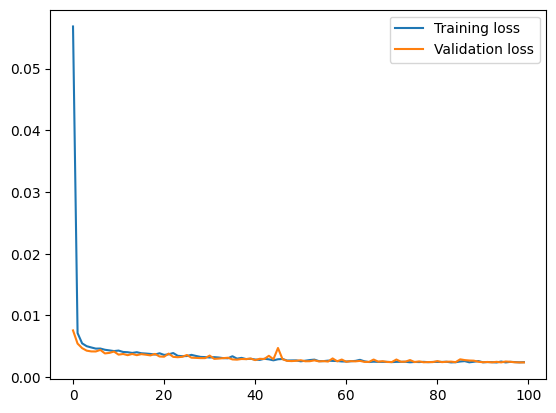

In [18]:
plt.plot(history.history['loss'], label = 'Training loss')
plt.plot(history.history['val_loss'], label = 'Validation loss')
plt.legend()
plt.show()

In [19]:
y_pred = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred)
y_test = scaler.inverse_transform(y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


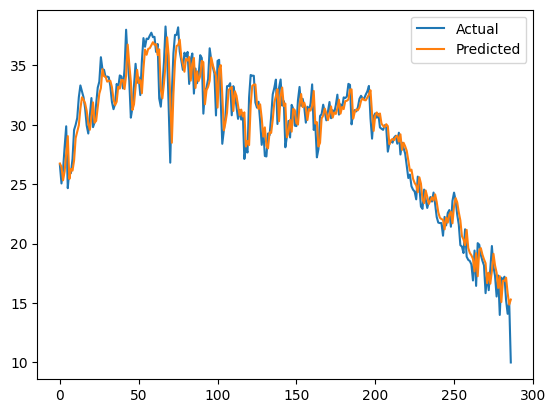

In [20]:
plt.plot(y_test, label = 'Actual')
plt.plot(y_pred, label = 'Predicted')
plt.legend()
plt.show()

In [21]:
last_30 = data[-30:]
last_30 = np.expand_dims(last_30, axis = 0)
next_temp = model.predict(last_30)
next_temp = scaler.inverse_transform(next_temp)
print("Next temperature: ", next_temp)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Next temperature:  [[11.910763]]
